In [1]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load sample dataset (Pandas / Seaborn)
df = sns.load_dataset('iris')

# 2. Separate features (X) and target label (y)
X = df.drop('species', axis=1)
y = df['species']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train a Machine Learning Model (Scikit-Learn)
model = RandomForestClassifier(n_estimators=50)
model.fit(X_train, y_train)

# 5. Evaluate
predictions = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions):.2%}")

Model Accuracy: 100.00%


Loading dataset...

--- Running 5-Fold Cross-Validation ---
5-Fold CV Scores: [0.91666667 0.95833333 0.95833333 0.95833333 0.95833333]
Mean CV Accuracy: 95.00% (+/- 3.33%)

Holdout Test Accuracy: 90.00%

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


Visualisations saved to 'model_visualisations.png'.


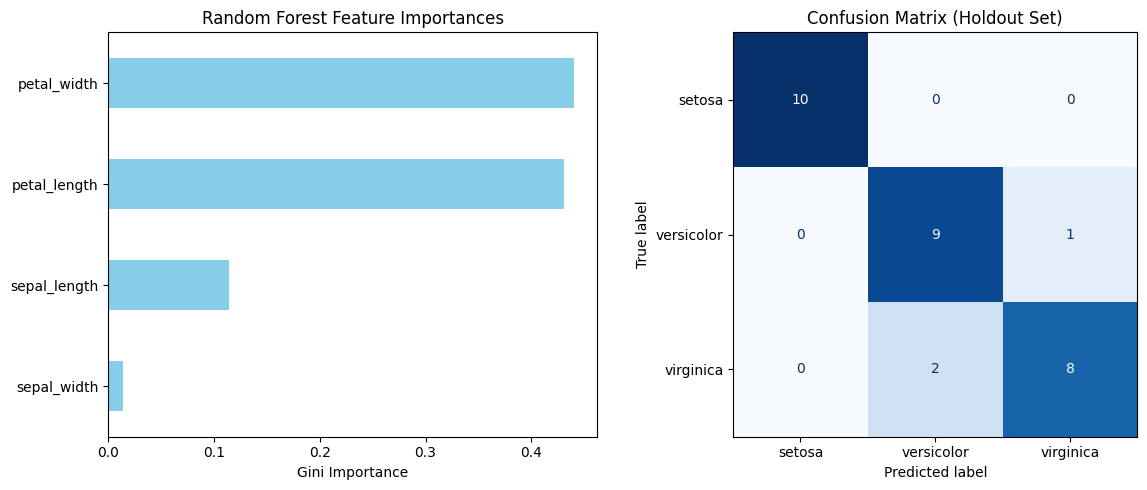

In [7]:
!pip install seaborn scikit-learn pandas matplotlib

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, train_test_split

# ==========================================
# 1. DATA INGESTION & EXPLORATION
# ==========================================
print("Loading dataset...")
df = sns.load_dataset('iris')

# Feature matrix (X) and target vector (y)
X = df.drop('species', axis=1)
y = df['species']

# ==========================================
# 2. MODEL VALIDATION SETUP
# ==========================================
# Train / Test Split (80% Train, 20% Holdout Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize Model
model = RandomForestClassifier(n_estimators=50, random_state=42)

# ==========================================
# 3. K-FOLD CROSS-VALIDATION
# ==========================================
print("\n--- Running 5-Fold Cross-Validation ---")
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print(f"5-Fold CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.2%} (+/- {cv_scores.std() * 2:.2%})")

# ==========================================
# 4. TRAIN & HOLDOUT EVALUATION
# ==========================================
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

holdout_accuracy = accuracy_score(y_test, y_pred)
print(f"\nHoldout Test Accuracy: {holdout_accuracy:.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==========================================
# 5. VISUALISATIONS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Feature Importance
feature_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
feature_imp.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Random Forest Feature Importances')
axes[0].set_xlabel('Gini Importance')

# Plot 2: Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap='Blues', ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix (Holdout Set)')

plt.tight_layout()
plt.savefig('model_visualisations.png', dpi=300)
print("\nVisualisations saved to 'model_visualisations.png'.")
plt.show()